# Hand Gesture Classification Using MediaPipe Landmarks from the HaGRID Dataset


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np

import cv2 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score


The dataset is hosted on Google Drive as a CSV file. We download it directly into a Pandas DataFrame using the file's share ID.

In [2]:
# file_id = '1cHrLgf_7xScBHxnvnlCkvAy_iYGscN3w'

# direct_link = f'https://drive.google.com/uc?export=download&id={file_id}'

# df = pd.read_csv(direct_link)

# df.head()

In [3]:
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

### About the Dataset

The 21 landmarks correspond to key anatomical points on the hand:

| Landmark | Description | Landmark | Description |
|----------|-------------|----------|-------------|
| 0 (Wrist) | Base of the hand | 11 | PIP of middle finger |
| 1 | CMC of thumb | 12 | DIP of middle finger  |
| 2 | MCP of thumb | 13 | Tip of middle finger |
| 3 | IP of thumb | 14 | MCP of ring finger |
| 4 | Tip of thumb | 15 | PIP of ring finger |
| 5 | MCP of index finger | 16 | DIP of ring finger |
| 6 | PIP of index finger | 17 | Tip of ring finger |
| 7 | DIP of index finger | 18 | MCP of pinky |
| 8 | Tip of index finger | 19 | PIP of pinky |
| 9 | MCP of middle finger | 20 | Tip of pinky |
| 10 | CMC of middle finger | | |

### Data Shape
- **Samples:** 25,675 hand gesture observations
- **Features:** 63 float columns (`x1, y1, z1, ..., x21, y21, z21`) — the 3D coordinates of each landmark
- **Target:** `label` — the gesture class (e.g., *call*, *dislike*, *fist*, *like*, *peace*, etc.)

### Missing Values Check

Confirm that there are **zero** missing values across the entire dataset.

In [5]:
df.isnull().sum().sum()

np.int64(0)

### Duplicate Rows Check

Confirm that there are **zero** duplicated values across the entire dataset.

In [6]:
df.duplicated().sum()

np.int64(0)

## 2. Data Visualization

### Data Distribution

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


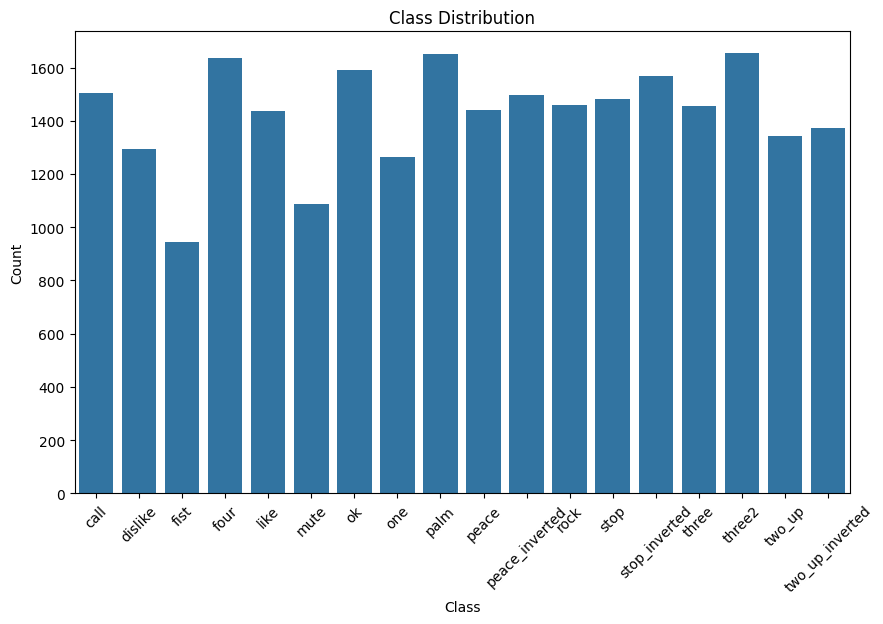

In [7]:
print(df['label'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Since the dataset contains **2D/3D landmark coordinates** (not raw images), we can reconstruct the hand skeleton by plotting the 21 landmarks and connecting them according to the **MediaPipe hand topology**.

The connections follow the natural finger structure:
- **Wrist** → base of each finger
- **Thumb:** 0 → 1 → 2 → 3 → 4
- **Index:** 0 → 5 → 6 → 7 → 8
- **Middle:** 0 → 9 → 10 → 11 → 12
- **Ring:** 0 → 13 → 14 → 15 → 16
- **Pinky:** 0 → 17 → 18 → 19 → 20

Below we visualize one random sample from each gesture class.

In [8]:
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),       # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),       # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20), # Pinky
    (5, 9), (9, 13), (13, 17)              # Palm
]


FINGER_COLORS = {
    'thumb':  '#FF6B6B',   
    'index':  '#4ECDC4',   
    'middle': '#45B7D1',   
    'ring':   '#96CEB4',   
    'pinky':  '#FFEAA7',   
    'palm':   '#DDA0DD'    
}


In [9]:
def plot_hand_landmarks(row, ax, title=''):
    # Extract x, y coordinates for all 21 landmarks (1-indexed in columns)
    xs = []
    ys = []

    for i in range(1, 22):
        xs.append(row[f'x{i}'])
        ys.append(row[f'y{i}'])

    # Draw connections
    for (i, j) in HAND_CONNECTIONS:
        ax.plot([xs[i], xs[j]], [ys[i], ys[j]], linewidth=2, alpha=0.8)

    # Draw landmark points
    ax.scatter(xs, ys, c='white', edgecolors='black',
               s=40, zorder=5, linewidths=1)

    # Highlight wrist and fingertips
    tips = [0, 4, 8, 12, 16, 20]
    ax.scatter([xs[t] for t in tips], [ys[t] for t in tips],
               c='#FF4757', edgecolors='black', s=70, zorder=6, linewidths=1)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.invert_yaxis()  
    ax.set_aspect('equal')
    ax.axis('off')


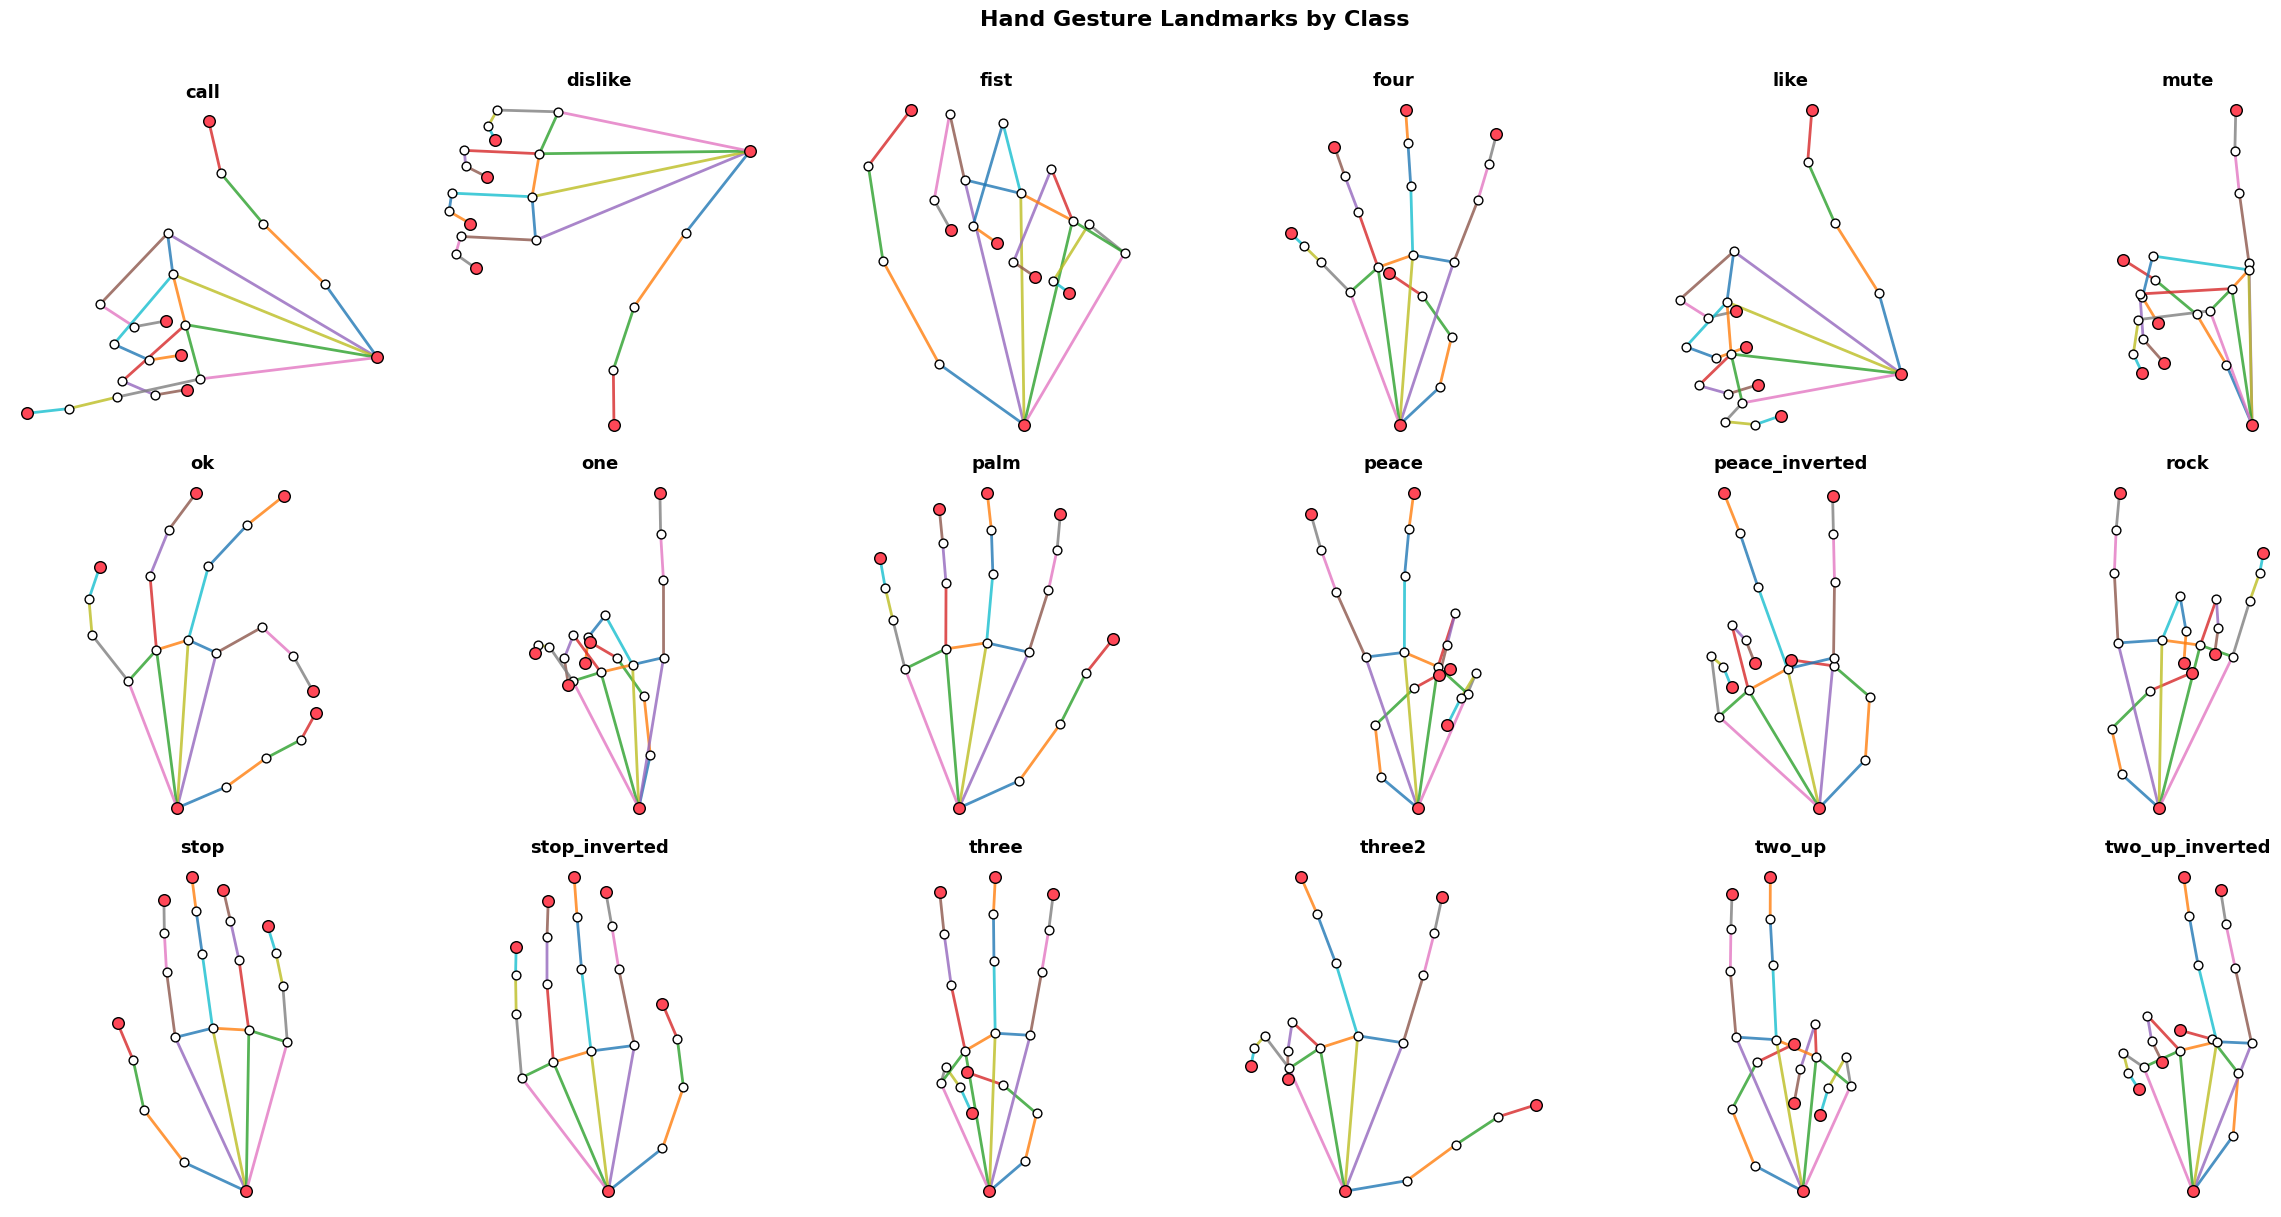

In [10]:
labels = sorted(df['label'].unique())
n_labels = len(labels)
cols = 6
rows = (n_labels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for idx, label in enumerate(labels):
    sample = df[df['label'] == label].sample(1, random_state=42).iloc[0]
    plot_hand_landmarks(sample, axes[idx], title=label)


fig.suptitle('Hand Gesture Landmarks by Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

### Normalize Landmarks

Raw landmark coordinates vary with hand position and size in the image. To make the features **translation- and scale-invariant**, we normalize each sample by:

1. **Centering** — subtract the **wrist** (landmark 1) coordinates so the wrist becomes the origin `(0, 0, 0)`.
2. **Scaling** — divide all coordinates by the **maximum absolute value** across the sample, so values fall roughly in `[-1, 1]`.

This ensures the model learns **hand shape and finger pose** rather than absolute pixel position or hand size.

In [11]:
def normalize_landmarks(df):
    """
    Normalize hand landmark coordinates to be translation- and scale-invariant.

    Steps:
      1. Center all landmarks relative to the wrist (landmark 1).
      2. Scale by the max absolute coordinate value so all values ∈ [-1, 1].

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns x1..x21, y1..y21, z1..z21, and 'label'.

    Returns
    -------
    pd.DataFrame
        Normalized DataFrame with the same structure.
    """
    df_norm = df.copy()

    # Column groups
    x_cols = [f'x{i}' for i in range(1, 22)]
    y_cols = [f'y{i}' for i in range(1, 22)]
    z_cols = [f'z{i}' for i in range(1, 22)]

    # --- Step 1: Center on the wrist (landmark 1) ---
    df_norm[x_cols] = df_norm[x_cols].subtract(df_norm['x1'], axis=0)
    df_norm[y_cols] = df_norm[y_cols].subtract(df_norm['y1'], axis=0)
    df_norm[z_cols] = df_norm[z_cols].subtract(df_norm['z1'], axis=0)

    # --- Step 2: Scale to [-1, 1] per sample ---
    all_landmark_cols = x_cols + y_cols + z_cols
    max_abs = df_norm[all_landmark_cols].abs().max(axis=1)
    # Avoid division by zero
    max_abs = max_abs.replace(0, 1)
    df_norm[all_landmark_cols] = df_norm[all_landmark_cols].div(max_abs, axis=0)

    return df_norm


df_normalized = normalize_landmarks(df)
df_normalized.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,0.0,-0.096086,-0.186520,0.000077,-0.288803,-0.285164,0.000106,-0.480858,...,-0.719398,-0.033189,-0.000374,-0.871268,0.014815,-0.000450,-1.0,0.042145,-0.000489,call
1,0.0,0.0,0.0,-0.020653,-0.253283,-0.000161,0.097400,-0.499767,-0.000305,0.177911,...,0.710769,-0.061735,-0.000553,0.860189,-0.046755,-0.000540,1.0,-0.044052,-0.000523,call
2,0.0,0.0,0.0,0.090383,-0.219744,-0.000002,0.228815,-0.428955,-0.000114,0.324483,...,0.733801,0.098171,-0.000517,0.876048,0.129541,-0.000475,1.0,0.141222,-0.000449,call
3,0.0,0.0,0.0,-0.011538,-0.269283,-0.000069,0.040473,-0.524538,-0.000217,0.066036,...,0.736797,-0.054535,-0.000673,0.879621,-0.045885,-0.000679,1.0,-0.049871,-0.000676,call
4,0.0,0.0,0.0,-0.005197,-0.261030,-0.000055,0.060380,-0.581850,-0.000154,0.071170,...,0.717926,-0.179280,-0.000476,0.872027,-0.209191,-0.000456,1.0,-0.250996,-0.000445,call


### Train Test Split

In [12]:
X = df_normalized.drop(columns=['label'])
y = df_normalized['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, shuffle=True, stratify=y)

In [14]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20540, 63)
y_train shape: (20540,)
X_test shape: (5135, 63)
y_test shape: (5135,)


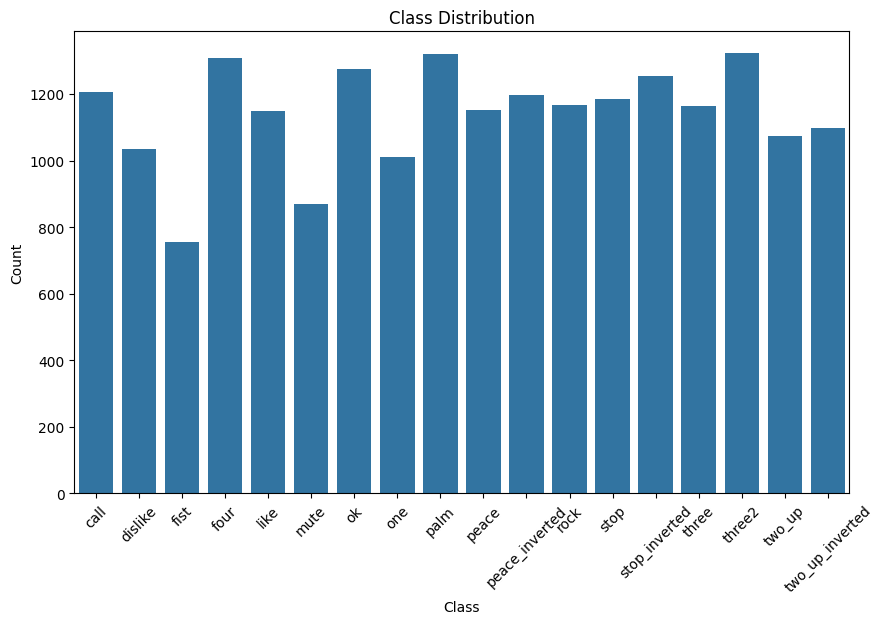

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x=sorted(y_train))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


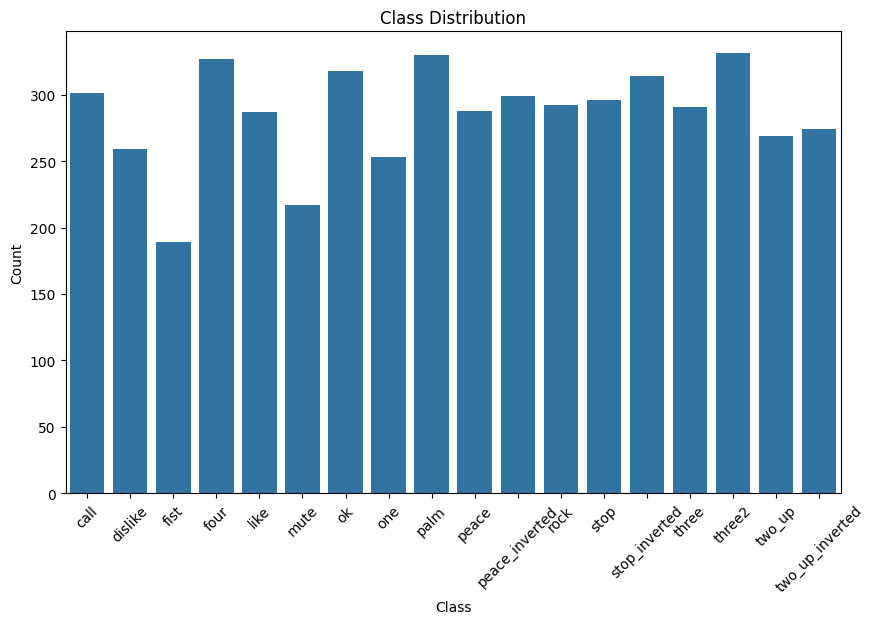

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x=sorted(y_test))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()